# Installation

In [ ]:
!pip install git+https://github.com/borongzhang/magpie_ptychography.git@main

# Imports

In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import h5py
from numpy.fft import fft2, ifft2, fftshift, ifftshift
import imageio.v2 as imageio
import random
import time
from magpie_ptychography.src import magpie_loop, rpie, lbfgs
from magpie_ptychography.src import feasibility_distance_misfit
from magpie_ptychography.src import generate_intensity_measurements, generate_scanning_positions


# Setup

In [2]:
# Size of the object
object_shape = (512, 512)

# Side length of the probe
n_probe = 128



## Realistic Synthetic Object and Probe

In [3]:
mat_data = scipy.io.loadmat('assets/recon_zoneplate_Yi.mat')
obj = mat_data['obj']
orgn_probe = mat_data['probe']

pad_x = (object_shape[0] - obj.shape[0]) // 2
pad_y = (object_shape[1] - obj.shape[1]) // 2

# Pad the object to the desired shape
real_object = np.pad(obj, ((pad_x, pad_x), (pad_y, pad_y)), mode='edge')

ratio = orgn_probe.shape[0] // n_probe

real_probe = orgn_probe[::ratio,::ratio]

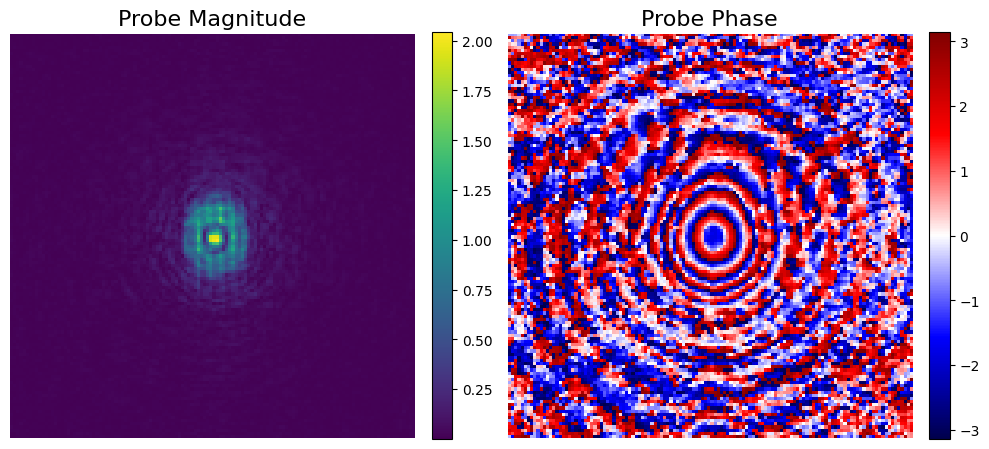

In [4]:
# Compute magnitude and phase
magnitude = np.abs(real_probe)
phase = np.angle(real_probe)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
im0 = ax.imshow(magnitude, cmap='viridis')
ax.set_title('Probe Magnitude', fontsize = 16)
ax.axis('off')
plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1]
im1 = ax.imshow(phase, cmap='seismic')
ax.set_title('Probe Phase', fontsize = 16)
ax.axis('off')
plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
#plt.savefig('probe_mag_phase.png', dpi=120, bbox_inches='tight')
plt.show()

## Test Synthetic Object 

In [5]:
# Load the images
baboon_image = imageio.imread('assets/baboon.tiff')
# Convert the Baboon image to grayscale 
if baboon_image.ndim == 3:
    baboon_image = np.mean(baboon_image, axis=2)
    
cameraman_image = imageio.imread('assets/cameraman.tif')
if cameraman_image.ndim == 3:
    cameraman_image = np.mean(cameraman_image, axis=2)

# Normalize the Baboon image to [0, 1] for magnitude
baboon_magnitude = baboon_image / np.max(baboon_image)

# Normalize the Cameraman image to [0, pi/2] for phase
cameraman_phase = (cameraman_image / np.max(cameraman_image)) * (np.pi / 2)

synthetic_object = baboon_magnitude * np.exp(1j * cameraman_phase)


/var/folders/26/rw2jcprn5qv45z71fxbk4t2w0000gn/T/ipykernel_14742/3075504364.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  cameraman_phase = (cameraman_image / np.max(cameraman_image)) * (np.pi / 2)
/var/folders/26/rw2jcprn5qv45z71fxbk4t2w0000gn/T/ipykernel_14742/3075504364.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  synthetic_object = baboon_magnitude * np.exp(1j * cameraman_phase)


/var/folders/26/rw2jcprn5qv45z71fxbk4t2w0000gn/T/ipykernel_14742/1642947703.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  magnitude = np.abs(synthetic_object)


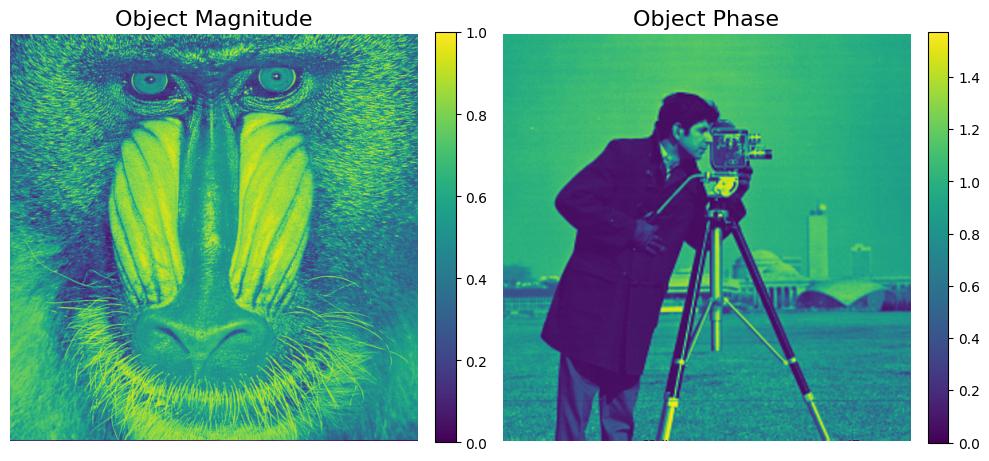

In [6]:
magnitude = np.abs(synthetic_object)
phase = np.angle(synthetic_object)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
im0 = ax.imshow(magnitude, cmap='viridis')
ax.set_title('Object Magnitude', fontsize = 16)
ax.axis('off')
plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1]
im1 = ax.imshow(phase, cmap='viridis')
ax.set_title('Object Phase', fontsize = 16)
ax.axis('off')
plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
#plt.savefig('synthetic_object.png', dpi=120, bbox_inches='tight')
plt.show()


## Data Generation

In [7]:
# Choose Object
probe = real_probe
ground_truth = synthetic_object

# Probe shift for intensity measurement
shift = 64

# Noise added to the measurement
noise_level = 0.05

# Define scanning positions
pos_array = generate_scanning_positions(object_shape, n_probe, shift)

# Generate the data
data = generate_intensity_measurements(ground_truth, probe, pos_array, noise_level)


# Numerical examples

In [8]:
misfit = feasibility_distance_misfit
z_initial = np.ones_like(ground_truth)
num_iterations = 3000
alpha_rpie = 0.01
print('The maximum level for MAGPIE is:', int(np.log2(probe.shape[0])))


The maximum level for MAGPIE is: 7


In [9]:
z_recon_rPIE, res_rPIE, errors_rPIE, tol_rPIE = rpie(z_initial, probe, data, pos_array, 
                                                num_iterations, misfit, ground_truth,
                                                alpha = alpha_rpie, metric = True, tol = 1e-4)


In [10]:
z_recon_MAGPIE_1, res_MAGPIE_1, errors_MAGPIE_1, tol_MAGPIE_1 = magpie_loop(z_initial, probe, data, pos_array, 
                                                   num_iterations, misfit, ground_truth,
                                                   alpha = alpha_rpie, metric = True, tol = 1e-4, max_level = 1)


In [11]:
z_recon_MAGPIE_2, res_MAGPIE_2, errors_MAGPIE_2, tol_MAGPIE_2 = magpie_loop(z_initial, probe, data, pos_array, 
                                                   num_iterations, misfit, ground_truth,
                                                   alpha = alpha_rpie, metric = True, tol = 1e-4, max_level = 2)


In [12]:
z_recon_MAGPIE_3, res_MAGPIE_3, errors_MAGPIE_3, tol_MAGPIE_3 = magpie_loop(z_initial, probe, data, pos_array, 
                                                   num_iterations, misfit, ground_truth,
                                                   alpha = alpha_rpie, metric = True, tol = 1e-4, max_level = 3)


In [13]:
z_recon_MAGPIE_4, res_MAGPIE_4, errors_MAGPIE_4, tol_MAGPIE_4 = magpie_loop(z_initial, probe, data, pos_array, 
                                                   num_iterations, misfit, ground_truth,
                                                   alpha = alpha_rpie, metric = True, tol = 1e-4, max_level = 4)


In [14]:
z_recon_MAGPIE_5, res_MAGPIE_5, errors_MAGPIE_5, tol_MAGPIE_5 = magpie_loop(z_initial, probe, data, pos_array, 
                                                   num_iterations, misfit, ground_truth,
                                                   alpha = alpha_rpie, metric = True, tol = 1e-4, max_level = 5)


In [15]:
z_recon_MAGPIE_6, res_MAGPIE_6, errors_MAGPIE_6, tol_MAGPIE_6 = magpie_loop(z_initial, probe, data, pos_array, 
                                                   num_iterations, misfit, ground_truth,
                                                   alpha = alpha_rpie, metric = True, tol = 1e-4, max_level = 6)


In [16]:
z_recon_MAGPIE_7, res_MAGPIE_7, errors_MAGPIE_7, tol_MAGPIE_7 = magpie_loop(z_initial, probe, data, pos_array, 
                                                   num_iterations, misfit, ground_truth,
                                                   alpha = alpha_rpie, metric = True, tol = 1e-4, max_level = 7)


In [17]:
zstar, eval_history_LBFGS, tol_LBFGS = lbfgs(z_initial, probe, data, pos_array, 
                                                   num_iterations, misfit, ground_truth, tol = 1e-4)


In [18]:
res_f_LBFGS = eval_history_LBFGS['f']
errors_LBFGS = eval_history_LBFGS['error']

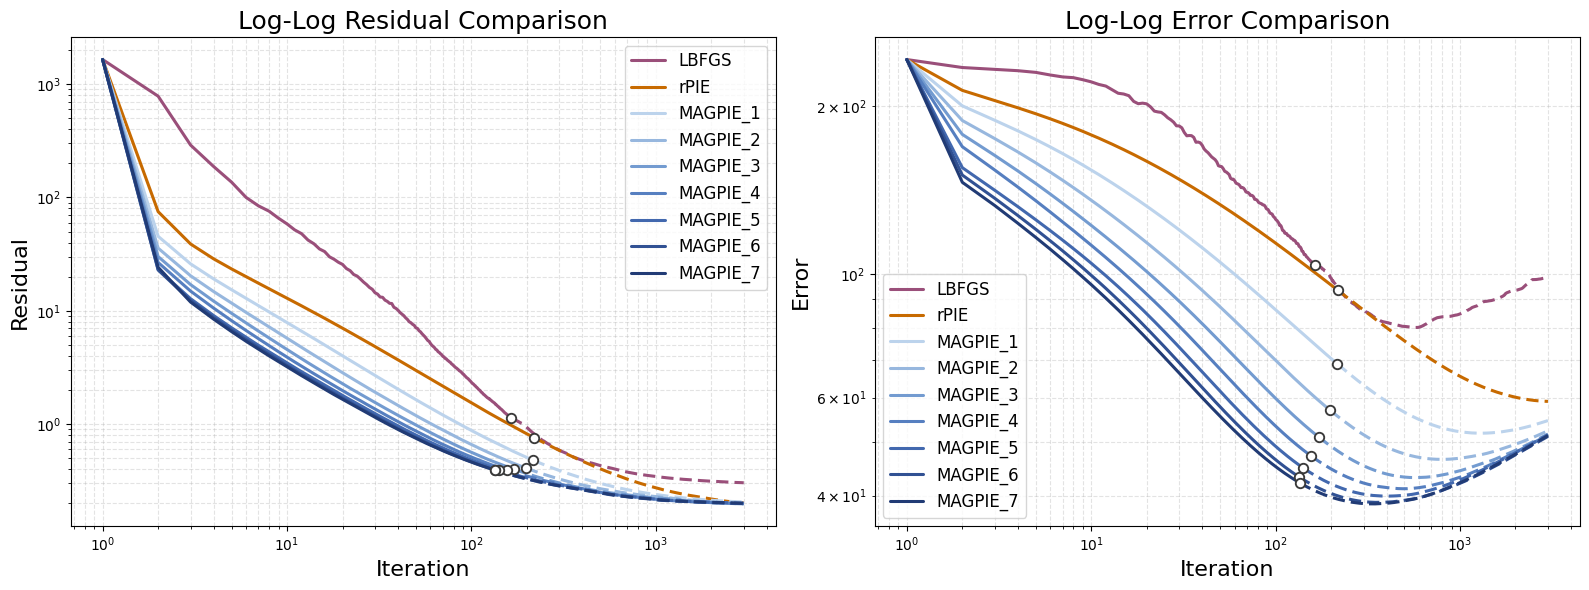

In [21]:
def plot_curve_with_tol(ax, values, tol_iter, label, color, lw=2.2):
    values = np.asarray(values)

    # x=1 is the initial point, x=j+1 corresponds to iteration j
    x = np.arange(1, len(values) + 1)
    y = values

    if len(x) == 0:
        return

    tol_x = None if tol_iter is None else int(tol_iter) + 1

    # Full curve if tol was never hit
    if tol_x is None or tol_x < 1 or tol_x > len(values):
        ax.plot(
            x, y,
            label=label,
            color=color,
            linewidth=lw,
            linestyle='-',
            solid_capstyle='round'
        )
        return

    mask_before = x <= tol_x
    mask_after  = x >= tol_x

    # Solid before tol
    ax.plot(
        x[mask_before], y[mask_before],
        label=label,
        color=color,
        linewidth=lw,
        linestyle='-',
        solid_capstyle='round'
    )

    # Dashed after tol, same color
    ax.plot(
        x[mask_after], y[mask_after],
        color=color,
        linewidth=lw,
        linestyle=(0, (4, 2)),
        solid_capstyle='round'
    )

    # Hollow circle marker
    ax.plot(
        tol_x, y[tol_x - 1],
        marker='o',
        markersize=6.8,
        linestyle='None',
        markerfacecolor='white',
        markeredgecolor='#3A3A3A',
        markeredgewidth=1.35,
        zorder=10
    )

# -------------------------
# Colors
# -------------------------

lbfgs_color = '#9A4F7A'   # deep berry-plum   <- my favorite


rpie_color  = '#C76A00'

magpie_colors = [
    '#BCD3EC',
    '#97B7DE',
    '#739BD0',
    '#567FC0',
    '#4268AE',
    '#315193',
    '#213B75',
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---------- Left subplot: Residuals ----------
plot_curve_with_tol(ax1, res_f_LBFGS,   tol_LBFGS,    'LBFGS',    lbfgs_color)
plot_curve_with_tol(ax1, res_rPIE,      tol_rPIE,     'rPIE',     rpie_color)
plot_curve_with_tol(ax1, res_MAGPIE_1,  tol_MAGPIE_1, 'MAGPIE_1', magpie_colors[0])
plot_curve_with_tol(ax1, res_MAGPIE_2,  tol_MAGPIE_2, 'MAGPIE_2', magpie_colors[1])
plot_curve_with_tol(ax1, res_MAGPIE_3,  tol_MAGPIE_3, 'MAGPIE_3', magpie_colors[2])
plot_curve_with_tol(ax1, res_MAGPIE_4,  tol_MAGPIE_4, 'MAGPIE_4', magpie_colors[3])
plot_curve_with_tol(ax1, res_MAGPIE_5,  tol_MAGPIE_5, 'MAGPIE_5', magpie_colors[4])
plot_curve_with_tol(ax1, res_MAGPIE_6,  tol_MAGPIE_6, 'MAGPIE_6', magpie_colors[5])
plot_curve_with_tol(ax1, res_MAGPIE_7,  tol_MAGPIE_7, 'MAGPIE_7', magpie_colors[6])

ax1.set_xlabel('Iteration', fontsize=16)
ax1.set_ylabel('Residual', fontsize=16)
ax1.set_title('Log-Log Residual Comparison', fontsize=18)
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.grid(True, which='both', linestyle='--', alpha=0.35)
ax1.legend(fontsize=12, frameon=True)

# ---------- Right subplot: Errors ----------
plot_curve_with_tol(ax2, errors_LBFGS,    tol_LBFGS,    'LBFGS',    lbfgs_color)
plot_curve_with_tol(ax2, errors_rPIE,     tol_rPIE,     'rPIE',     rpie_color)
plot_curve_with_tol(ax2, errors_MAGPIE_1, tol_MAGPIE_1, 'MAGPIE_1', magpie_colors[0])
plot_curve_with_tol(ax2, errors_MAGPIE_2, tol_MAGPIE_2, 'MAGPIE_2', magpie_colors[1])
plot_curve_with_tol(ax2, errors_MAGPIE_3, tol_MAGPIE_3, 'MAGPIE_3', magpie_colors[2])
plot_curve_with_tol(ax2, errors_MAGPIE_4, tol_MAGPIE_4, 'MAGPIE_4', magpie_colors[3])
plot_curve_with_tol(ax2, errors_MAGPIE_5, tol_MAGPIE_5, 'MAGPIE_5', magpie_colors[4])
plot_curve_with_tol(ax2, errors_MAGPIE_6, tol_MAGPIE_6, 'MAGPIE_6', magpie_colors[5])
plot_curve_with_tol(ax2, errors_MAGPIE_7, tol_MAGPIE_7, 'MAGPIE_7', magpie_colors[6])

ax2.set_xlabel('Iteration', fontsize=16)
ax2.set_ylabel('Error', fontsize=16)
ax2.set_title('Log-Log Error Comparison', fontsize=18)
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.grid(True, which='both', linestyle='--', alpha=0.35)
ax2.legend(fontsize=12, frameon=True, loc='lower left')

plt.tight_layout()
plt.savefig('metric_1.png', dpi=200, bbox_inches='tight')
plt.show()


/var/folders/26/rw2jcprn5qv45z71fxbk4t2w0000gn/T/ipykernel_14742/2753234302.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  intensity_ground_truth = np.abs(ground_truth)
/var/folders/26/rw2jcprn5qv45z71fxbk4t2w0000gn/T/ipykernel_14742/2753234302.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  intensity_LBFGS, phase_LBFGS = np.abs(LBFGS_image), np.angle(LBFGS_image)
/var/folders/26/rw2jcprn5qv45z71fxbk4t2w0000gn/T/ipykernel_14742/2753234302.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  intensity_rPIE, phase_rPIE = np.abs(rPIE_image), np.angle(rPIE_image)
/var/folders/26/rw2jcprn5qv45z71fxbk4t2w0000gn/T/ipykernel_14742/2753234302.py:16: DeprecationWarning: __array_wrap__ must accept context and return

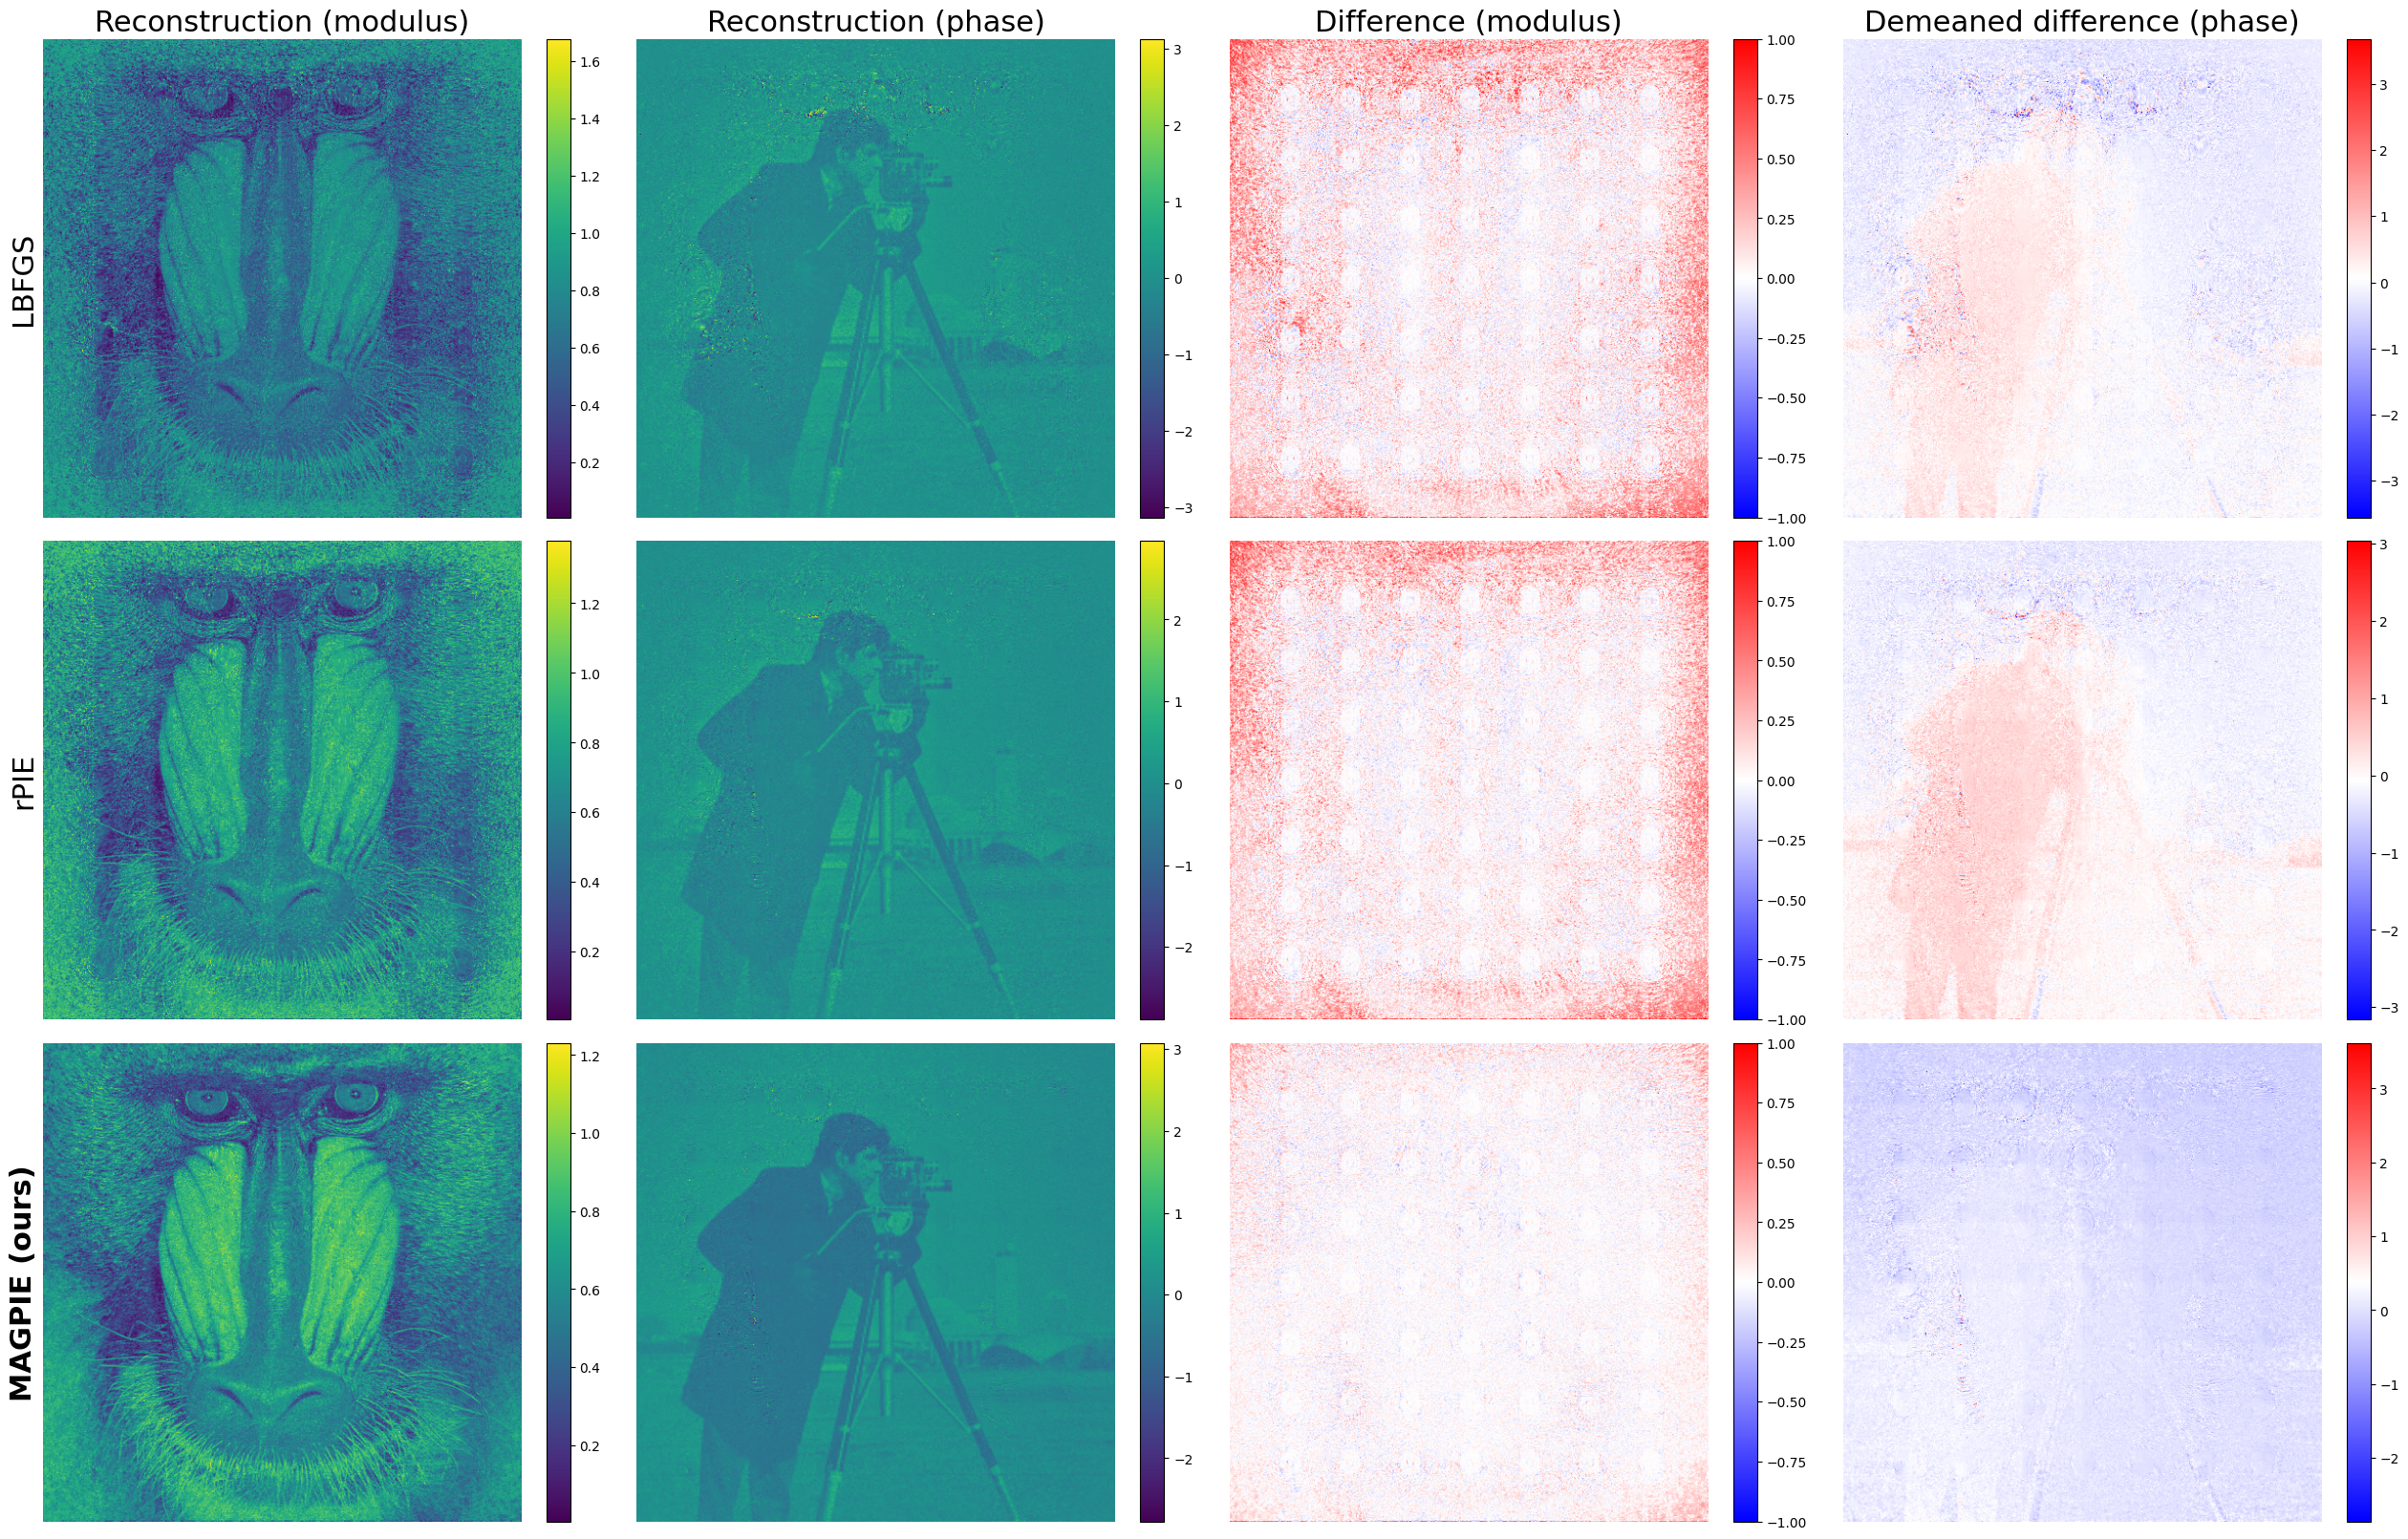

In [23]:
size = object_shape
rPIE_image = z_recon_rPIE
MAGPIE_image = z_recon_MAGPIE_7
LBFGS_image = zstar.view(np.complex128).reshape(object_shape)

intensity_ground_truth = np.abs(ground_truth)
phase_ground_truth = np.angle(ground_truth)

def calculate_difference(image, ground_truth):
    intensity_diff = np.abs(image) - intensity_ground_truth
    phase_diff = np.angle(image) - phase_ground_truth - np.mean(np.angle(image) - phase_ground_truth)
    return intensity_diff, phase_diff

intensity_LBFGS, phase_LBFGS = np.abs(LBFGS_image), np.angle(LBFGS_image)
intensity_rPIE, phase_rPIE = np.abs(rPIE_image), np.angle(rPIE_image)
intensity_MAGPIE, phase_MAGPIE = np.abs(MAGPIE_image), np.angle(MAGPIE_image)

# Calculate differences
intensity_diff_LBFGS, phase_diff_LBFGS = calculate_difference(LBFGS_image, ground_truth)
intensity_diff_rPIE, phase_diff_rPIE = calculate_difference(rPIE_image, ground_truth)
intensity_diff_MAGPIE, phase_diff_MAGPIE = calculate_difference(MAGPIE_image, ground_truth)

# Updated column titles and row labels
column_titles = [
    "Reconstruction (modulus)", 
    "Reconstruction (phase)", 
    "Difference (modulus)", 
    "Demeaned difference (phase)"
]
row_labels = ["LBFGS", "rPIE", "MAGPIE (ours)"]

# Prepare data for plotting: each tuple contains (intensity, phase, intensity_diff, phase_diff)
image_data = [
    (intensity_LBFGS, phase_LBFGS, intensity_diff_LBFGS, phase_diff_LBFGS),
    (intensity_rPIE, phase_rPIE, intensity_diff_rPIE, phase_diff_rPIE),
    (intensity_MAGPIE, phase_MAGPIE, intensity_diff_MAGPIE, phase_diff_MAGPIE),
]

# Create a new figure using subplots 
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(25, 16), constrained_layout=True)

# Set column titles on the first row.
for j, title in enumerate(column_titles):
    axes[0, j].set_title(title, fontsize=22)

# Loop over each row of image data.
for i, (intensity, phase, intensity_diff, phase_diff) in enumerate(image_data):
    # Set the row label for the first column.
    if i == 2:
        axes[i, 0].set_ylabel(row_labels[i], fontsize=22, fontweight='bold')
    else:
        axes[i, 0].set_ylabel(row_labels[i], fontsize=22)

    # Remove spines and ticks for clarity.
    for j in range(4):
        ax = axes[i, j]
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])

    # Plot the intensity image.
    im0 = axes[i, 0].imshow(intensity, cmap='viridis')
    fig.colorbar(im0, ax=axes[i, 0])

    # Plot the phase image.
    im1 = axes[i, 1].imshow(phase, cmap='viridis')
    fig.colorbar(im1, ax=axes[i, 1])
    
    # Plot the intensity difference image with symmetric scaling.
    max_intensity_diff = np.max(np.abs(intensity_diff))
    im2 = axes[i, 2].imshow(intensity_diff, cmap='bwr', vmin=-1, vmax=1)
    fig.colorbar(im2, ax=axes[i, 2])

    # Plot the phase difference image with symmetric scaling.
    max_phase_diff = np.max(np.abs(phase_diff))
    im3 = axes[i, 3].imshow(phase_diff, cmap='bwr')
    fig.colorbar(im3, ax=axes[i, 3])

plt.savefig('reconstruction_1.png', dpi=60, bbox_inches='tight')
plt.show()